In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/geethesh1911/baseline-cnn/Baseline_CNN.pth
/kaggle/input/datasets/geethesh1911/advancedcnn/Advanced_CNN_1.pth
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/LICENSE
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/README.md
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50-human.xlsx
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-257349-A-15.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-195557-A-19.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/2-122820-B-36.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-115920-A-22.wav
/kaggle/input/jan-2026-dl-gen-ai-

In [2]:
#Modules
!pip install -q wandb torchaudio

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import wandb
from kaggle_secrets import UserSecretsClient
from transformers import AutoFeatureExtractor, ASTForAudioClassification, get_cosine_schedule_with_warmup
import matplotlib.pyplot as plt
import librosa
import librosa.display

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
#WandB and Setup

user_secrets = UserSecretsClient()
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")
wandb.login()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

data_dir = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup" 
stems_dir = f"{data_dir}/genres_stems"
noise_dir = f"{data_dir}/ESC-50-master/audio"
test_dir = f"{data_dir}/mashups"

genres = ["blues", "classical", "country", "disco", "hiphop", 
          "jazz", "metal", "pop", "reggae", "rock"]
genre_mapping = {g: i for i, g in enumerate(genres)}

torch.manual_seed(42)
np.random.seed(42)

all_songs = []
for g in genres:
    g_path = os.path.join(stems_dir, g)
    if os.path.exists(g_path):
        for folder in os.listdir(g_path):
            f_path = os.path.join(g_path, folder)
            if os.path.isdir(f_path):
                all_songs.append((f_path, genre_mapping[g]))

labels = [lbl for _, lbl in all_songs]
train_list, val_list = train_test_split(all_songs, test_size=0.2, random_state=42, stratify=labels)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Currently logged in as: geethesh1911 (geethesh1911-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Device: cuda


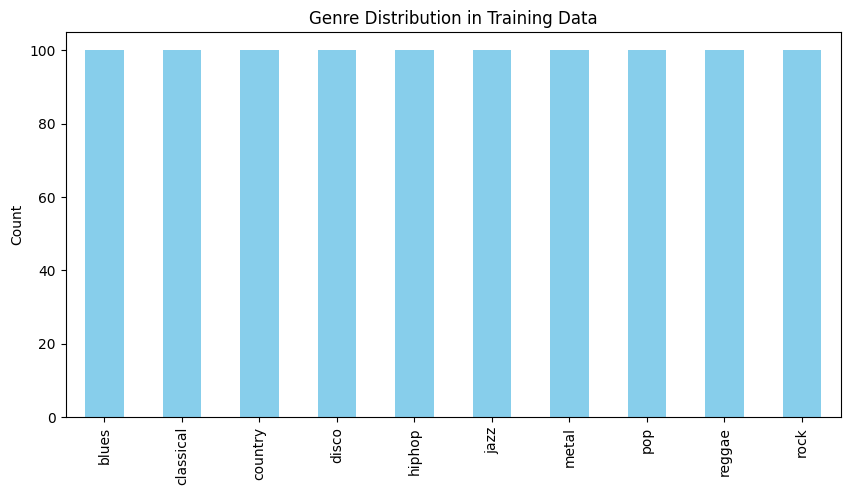

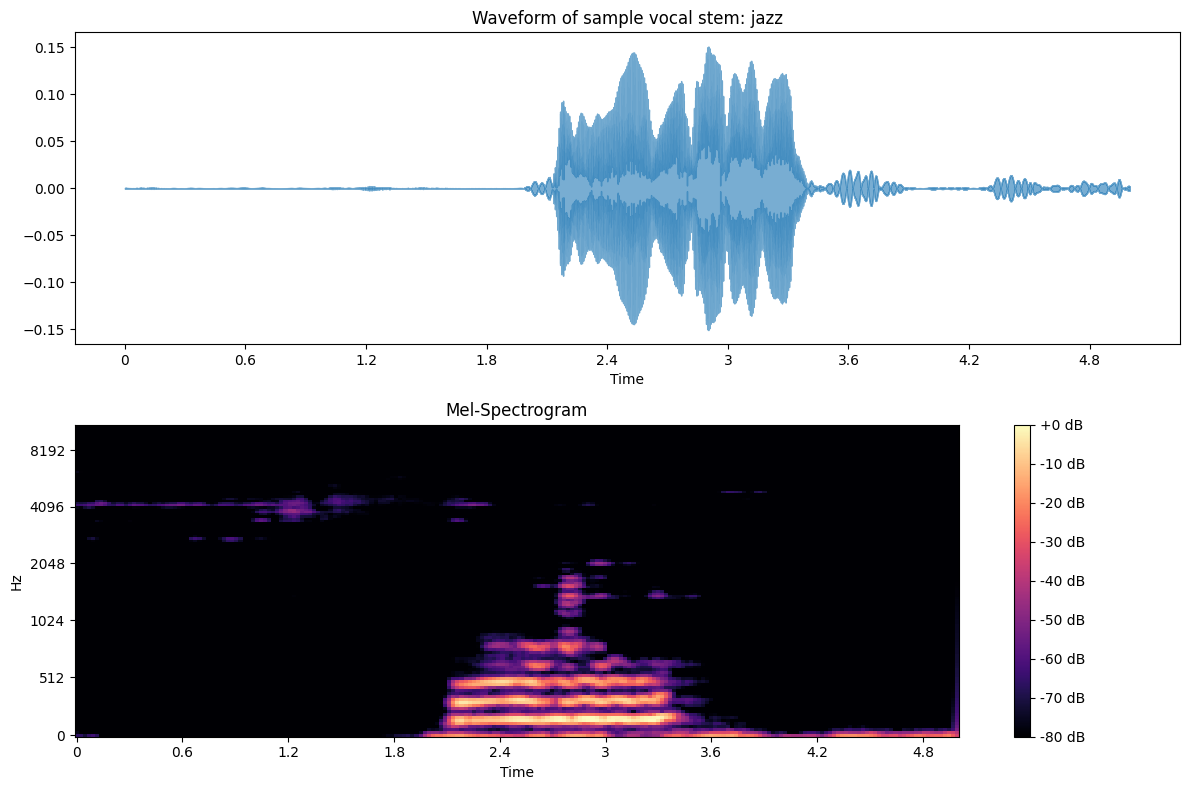

In [4]:
plt.figure(figsize=(10, 5))
pd.Series([genres[lbl] for lbl in labels]).value_counts().plot(kind='bar', color='skyblue')
plt.title("Genre Distribution in Training Data")
plt.ylabel("Count")
plt.show

sample_song = train_list[0][0]

sample_stem = os.path.join(sample_song, 'vocals.wav')
y, sr = librosa.load(sample_stem, sr=22050, duration=5.0)
    
plt.figure(figsize=(12, 8))
    
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr, alpha=0.6)
plt.title(f"Waveform of sample vocal stem: {genres[train_list[0][1]]}")
    
plt.subplot(2, 1, 2)
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr)
plt.colorbar(img, format='%+2.0f dB')
plt.title("Mel-Spectrogram")
plt.tight_layout()
plt.show()

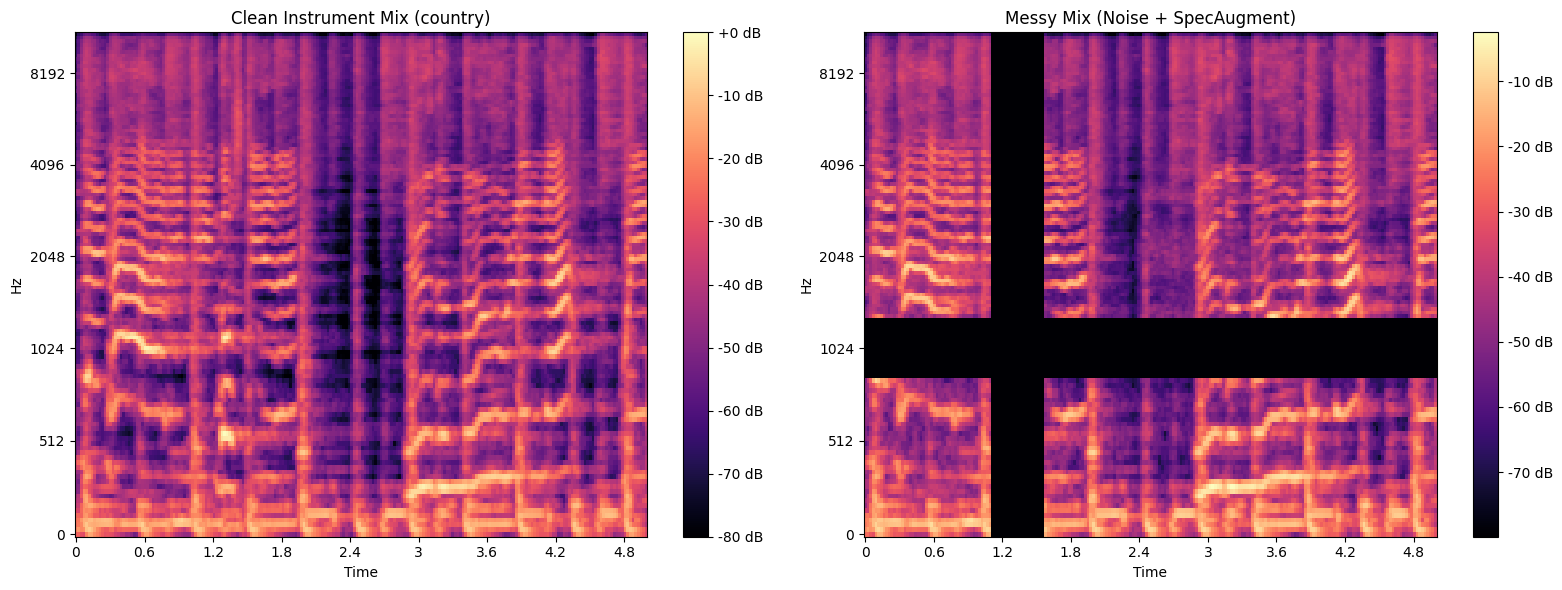

In [5]:
sample_song = train_list[1][0]

clean_mix = None
for stem in ['vocals.wav', 'drums.wav', 'bass.wav', 'others.wav']:
    stem_path = os.path.join(sample_song, stem)
    if os.path.exists(stem_path):
        y, _ = librosa.load(stem_path, sr=22050, duration=5.0)
        clean_mix = y if clean_mix is None else clean_mix + y

messy_mix = clean_mix.copy()
noise_files = [os.path.join(noise_dir, f) for f in os.listdir(noise_dir) if f.endswith('.wav')]
if noise_files:
    noise, _ = librosa.load(random.choice(noise_files), sr=22050, duration=5.0)
    if len(noise) > len(messy_mix): noise = noise[:len(messy_mix)]
    else: noise = np.pad(noise, (0, len(messy_mix) - len(noise)))
    messy_mix = messy_mix + (noise * 0.4)

S_clean = librosa.power_to_db(librosa.feature.melspectrogram(y=clean_mix, sr=22050, n_mels=128), ref=np.max)
S_messy = librosa.power_to_db(librosa.feature.melspectrogram(y=messy_mix, sr=22050, n_mels=128), ref=np.max)
f0, f_width = random.randint(0, 40), 15
t0, t_width = random.randint(0, S_messy.shape[1]-20), 20
S_messy[f0:f0+f_width, :] = S_messy.min() 
S_messy[:, t0:t0+t_width] = S_messy.min() 

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
img1 = librosa.display.specshow(S_clean, x_axis='time', y_axis='mel', sr=22050, ax=ax[0])
ax[0].set_title(f"Clean Instrument Mix ({genres[train_list[1][1]]})")
fig.colorbar(img1, ax=ax[0], format="%+2.0f dB")

img2 = librosa.display.specshow(S_messy, x_axis='time', y_axis='mel', sr=22050, ax=ax[1], cmap='magma')
ax[1].set_title("Messy Mix (Noise + SpecAugment)")
fig.colorbar(img2, ax=ax[1], format="%+2.0f dB")
plt.tight_layout()
plt.show()

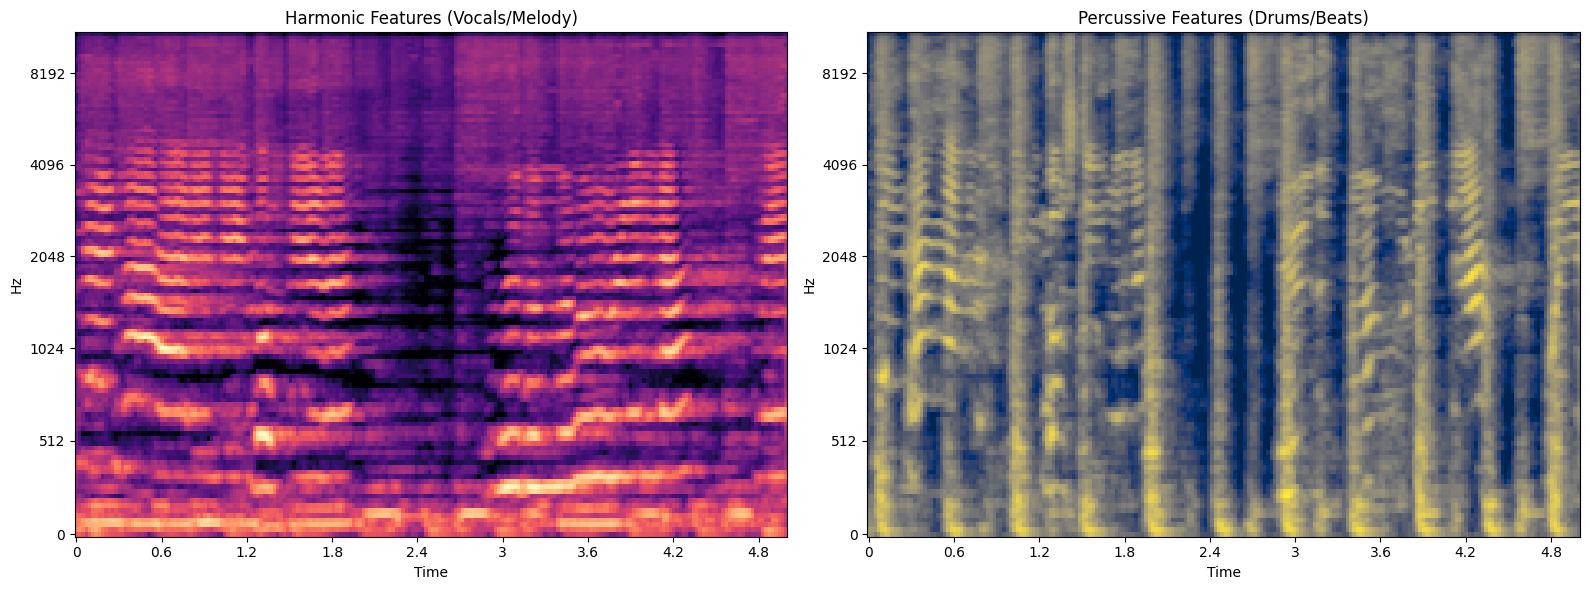

In [6]:
y_harmonic, y_percussive = librosa.effects.hpss(clean_mix)

S_harmonic = librosa.power_to_db(librosa.feature.melspectrogram(y=y_harmonic, sr=22050, n_mels=128), ref=np.max)
S_percussive = librosa.power_to_db(librosa.feature.melspectrogram(y=y_percussive, sr=22050, n_mels=128), ref=np.max)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
librosa.display.specshow(S_harmonic, x_axis='time', y_axis='mel', sr=22050, ax=ax[0])
ax[0].set_title("Harmonic Features (Vocals/Melody)")

librosa.display.specshow(S_percussive, x_axis='time', y_axis='mel', sr=22050, ax=ax[1], cmap='cividis')
ax[1].set_title("Percussive Features (Drums/Beats)")
plt.tight_layout()
plt.show()

In [7]:
class AudioDataset(Dataset):
    def __init__(self,song_paths,noise_dir,target_sr=22050,duration=5,augment=False):
        self.song_paths=song_paths
        self.noise_files=[os.path.join(noise_dir,f) for f in os.listdir(noise_dir) if f.endswith('.wav')]
        self.target_sr=target_sr
        self.num_samples=target_sr*duration
        self.augment=augment
        self.stems=['vocals.wav','drums.wav','bass.wav','others.wav']
        self.mel_transform=T.MelSpectrogram(sample_rate=target_sr,n_fft=1024,hop_length=512,n_mels=64)
        self.db_transform=T.AmplitudeToDB()
        
    def __len__(self):
        return len(self.song_paths)
        
    def _load_audio(self,filepath):
        wav,sr=torchaudio.load(filepath)
        if sr!=self.target_sr:
            wav=T.Resample(sr,self.target_sr)(wav)
        if wav.shape[0]>1:
            wav=torch.mean(wav,dim=0,keepdim=True)
        return wav
        
    def __getitem__(self,idx):
        with torch.no_grad():
            song_path,label=self.song_paths[idx]
            mixed=None
            for stem in self.stems:
                stem_path=os.path.join(song_path,stem)
                if os.path.exists(stem_path):
                    wav=self._load_audio(stem_path)
                    if mixed is None:
                        mixed=wav
                    else:
                        min_l=min(mixed.shape[1],wav.shape[1])
                        mixed=mixed[:,:min_l]+wav[:,:min_l]
            if self.augment:
                if self.noise_files and random.random()>0.5:
                    noise_path=random.choice(self.noise_files)
                    noise=self._load_audio(noise_path)
                    if noise.shape[1]>mixed.shape[1]:
                        noise=noise[:,:mixed.shape[1]]
                    else:
                        noise=torch.nn.functional.pad(noise,(0,mixed.shape[1]-noise.shape[1]))
                    mixed=mixed+(noise*random.uniform(0.01,0.05))
                mixed=mixed*random.uniform(0.9,1.1)
            if mixed.shape[1]>self.num_samples:
                start=random.randint(0,mixed.shape[1]-self.num_samples)
                mixed=mixed[:,start:start+self.num_samples]
            else:
                mixed=torch.nn.functional.pad(mixed,(0,self.num_samples-mixed.shape[1]))
            spec=self.mel_transform(mixed)
            spec=self.db_transform(spec)
            if self.augment:
                if random.random()>0.7:
                    f0=random.randint(0,60)
                    spec[:,f0:f0+4,:]=0
                if random.random()>0.7:
                    t0=random.randint(0,spec.shape[2]-10)
                    spec[:,:,t0:t0+10]=0
            spec=(spec-spec.mean())/(spec.std()+1e-6)
            return spec.detach(),label

In [8]:
class AdvancedCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [9]:
class BiLSTM(nn.Module):
    def __init__(self,input_size=64,hidden_size=128,num_classes=10):
        super().__init__()
        self.lstm=nn.LSTM(input_size=input_size,hidden_size=hidden_size,num_layers=2,batch_first=True,bidirectional=True,dropout=0.3)
        self.classifier=nn.Sequential(nn.Linear(hidden_size*2,64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,num_classes))
    def forward(self,x):
        x=x.squeeze(1)
        x=x.permute(0,2,1)
        lstm_out,(hidden,cell)=self.lstm(x)
        x=torch.mean(lstm_out,dim=1)
        x=self.classifier(x)
        return x

In [10]:
def train_basic_model(model, name, train_loader, val_loader, epochs=20, lr=1e-3):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    wandb.init(
        project="23f2003015-t12026",
        name=name,
        config={
            "epochs": epochs,
            "lr": lr,
            "batch_size": train_loader.batch_size,
            "optimizer": "AdamW",
            "weight_decay": 1e-4,
            "label_smoothing": 0.1
        }
    )
    best_f1 = 0.0
    patience = 5
    no_improve = 0
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        model.eval()
        val_loss = 0
        preds, targets = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item()
                p = torch.argmax(out, dim=1)
                preds.extend(p.cpu().numpy())
                targets.extend(y.cpu().numpy())
                
        t_loss = train_loss / len(train_loader)
        v_loss = val_loss / len(val_loader)
        f1 = f1_score(targets, preds, average='macro')
        
        scheduler.step(f1)
        current_lr = optimizer.param_groups[0]["lr"]
        
        if f1 > best_f1:
            best_f1 = f1
            no_improve = 0
            torch.save(model.state_dict(), f"/kaggle/working/{name}.pth")
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping triggered.")
                break
        
        wandb.log({
            "epoch": epoch,
            "train_loss": t_loss,
            "val_loss": v_loss,
            "val_f1": f1,
            "lr": current_lr,
            "best_val_f1": best_f1
        })
        
        print(f"Epoch {epoch} | Train Loss: {t_loss:.4f} | Val F1: {f1:.4f}")
                
    wandb.finish()
    return best_f1

In [11]:
test_csv_path=f"{data_dir}/test.csv"
test_df=pd.read_csv(test_csv_path)

# # --- 1. Train CNN & BiLSTM ---
# train_ds_basic = AudioDataset(train_list, noise_dir, augment=True)
# val_ds_basic = AudioDataset(val_list, noise_dir, augment=False)
# train_loader_basic = DataLoader(train_ds_basic, batch_size=32, shuffle=True, num_workers=2)
# val_loader_basic = DataLoader(val_ds_basic, batch_size=32, shuffle=False, num_workers=2)

# print("Training CNN...")
# model_cnn = AdvancedCNN(num_classes=10).to(device)
# train_basic_model(model_cnn, "Advanced_CNN", train_loader_basic, val_loader_basic, epochs=25)

# print("Training BiLSTM...")
# model_bilstm = BiLSTM(num_classes=10).to(device)
# train_basic_model(model_bilstm, "BiLSTM", train_loader_basic, val_loader_basic, epochs=30)

# # --- 2. Standard Test Dataset for CNN/BiLSTM ---
# class StandardTestDataset(Dataset):
#     def __init__(self, df, test_dir, target_sr=22050, duration=5):
#         self.df = df
#         self.test_dir = test_dir
#         self.target_sr = target_sr
#         self.num_samples = target_sr * duration
#         self.mel_transform = T.MelSpectrogram(sample_rate=target_sr, n_fft=1024, hop_length=512, n_mels=64)
#         self.db_transform = T.AmplitudeToDB()
        
#     def __len__(self):
#         return len(self.df)
        
#     def __getitem__(self, idx):
#         file_id = str(self.df.iloc[idx]['id']).zfill(4)
#         file_path = os.path.join(self.test_dir, f"song{file_id}.wav")
#         wav, sr = torchaudio.load(file_path)
#         if sr != self.target_sr:
#             wav = T.Resample(sr, self.target_sr)(wav)
#         if wav.shape[0] > 1:
#             wav = torch.mean(wav, dim=0, keepdim=True)
#         if wav.shape[1] > self.num_samples:
#             start = (wav.shape[1] - self.num_samples) // 2
#             wav = wav[:, start:start+self.num_samples]
#         else:
#             wav = torch.nn.functional.pad(wav, (0, self.num_samples - wav.shape[1]))
#         spec = self.db_transform(self.mel_transform(wav))
#         spec = (spec - spec.mean()) / (spec.std() + 1e-6)
#         return spec, file_id

# test_ds_standard = StandardTestDataset(test_df, test_dir)
# test_loader_standard = DataLoader(test_ds_standard, batch_size=32, shuffle=False, num_workers=2)

# # --- 3. CNN & BiLSTM Inference ---
# def run_standard_inference(model, model_path, output_csv):
#     model.load_state_dict(torch.load(model_path, map_location=device))
#     model.eval()
#     predictions, file_ids = [], []
#     with torch.no_grad():
#         for specs, ids in test_loader_standard:
#             specs = specs.to(device)
#             out = model(specs)
#             preds = torch.argmax(out, dim=1).cpu().numpy()
#             predictions.extend(preds)
#             file_ids.extend(ids)
    
#     idx_mapping = {v: k for k, v in genre_mapping.items()}
#     pred_labels = [idx_mapping[p] for p in predictions]
#     pd.DataFrame({'id': file_ids, 'genre': pred_labels}).to_csv(output_csv, index=False)
#     print(f"Saved {output_csv}")

# # run_standard_inference(model_cnn, "/kaggle/working/Advanced_CNN.pth", "/kaggle/working/cnn_submission.csv")
# # run_standard_inference(model_bilstm, "/kaggle/working/BiLSTM.pth", "/kaggle/working/bilstm_submission.csv")

In [12]:
extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

class ASTDataset(Dataset):
    def __init__(self,song_paths,noise_dir,target_sr=16000,duration=5,augment=False):
        self.song_paths=song_paths
        self.noise_files=[os.path.join(noise_dir,f) for f in os.listdir(noise_dir) if f.endswith('.wav')]
        self.target_sr=target_sr
        self.num_samples=target_sr*duration
        self.stems=['vocals.wav','drums.wav','bass.wav','others.wav']
        self.augment=augment
        
    def __len__(self):
        return len(self.song_paths)
        
    def __getitem__(self,idx):
        with torch.no_grad():
            song_path,label=self.song_paths[idx]
            mixed=None
            for stem in self.stems:
                stem_path=os.path.join(song_path,stem)
                if os.path.exists(stem_path):
                    wav,sr=torchaudio.load(stem_path)
                    if sr!=self.target_sr:
                        wav=T.Resample(sr,self.target_sr)(wav)
                    if wav.shape[0]>1:
                        wav=torch.mean(wav,dim=0,keepdim=True)
                    if self.augment:
                        if random.random()<0.15:
                            continue
                        wav=wav*random.uniform(0.4,1.6)
                    if mixed is None:
                        mixed=wav
                    else:
                        min_l=min(mixed.shape[1],wav.shape[1])
                        mixed=mixed[:,:min_l]+wav[:,:min_l]
                        
            if mixed is None:
                mixed=torch.zeros(1,self.num_samples)
                
            if self.augment and self.noise_files and random.random()>0.4:
                noise_path=random.choice(self.noise_files)
                noise,n_sr=torchaudio.load(noise_path)
                if n_sr!=self.target_sr:
                    noise=T.Resample(n_sr,self.target_sr)(noise)
                if noise.shape[0]>1:
                    noise=torch.mean(noise,dim=0,keepdim=True)
                if noise.shape[1]>mixed.shape[1]:
                    noise=noise[:,:mixed.shape[1]]
                else:
                    noise=torch.nn.functional.pad(noise,(0,mixed.shape[1]-noise.shape[1]))
                mixed=mixed+(noise*random.uniform(0.1,0.5))
                
            if mixed.shape[1]>self.num_samples:
                start=random.randint(0,mixed.shape[1]-self.num_samples)
                mixed=mixed[:,start:start+self.num_samples]
            else:
                mixed=torch.nn.functional.pad(mixed,(0,self.num_samples-mixed.shape[1]))
            inputs=extractor(mixed.squeeze().numpy(),sampling_rate=self.target_sr,return_tensors="pt")
            return inputs.input_values.squeeze(0),label

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

In [13]:
def train_model_hf(model,name,train_loader,val_loader,epochs=10,lr=5e-5):
    criterion=nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer=optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-4)
    scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='max',factor=0.5,patience=2)
    wandb.init(project="23f2003015-t12026",name=name,config={"epochs":epochs,"lr":lr})
    best_f1=0.0
    no_improve=0
    for epoch in range(epochs):
        model.train()
        train_loss=0
        for x,y in train_loader:
            x,y=x.to(device),y.to(device)
            optimizer.zero_grad()
            out=model(x).logits
            loss=criterion(out,y)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()
        model.eval()
        val_loss=0
        preds,targets=[],[]
        with torch.no_grad():
            for x,y in val_loader:
                x,y=x.to(device),y.to(device)
                out=model(x).logits
                loss=criterion(out,y)
                val_loss+=loss.item()
                p=torch.argmax(out,dim=1)
                preds.extend(p.cpu().numpy())
                targets.extend(y.cpu().numpy())
            t_loss=train_loss/len(train_loader)
        v_loss=val_loss/len(val_loader)
        f1=f1_score(targets,preds,average='macro')
        scheduler.step(f1)
        if f1>best_f1:
            best_f1=f1
            no_improve=0
            torch.save(model.state_dict(),f"/kaggle/working/{name}.pth")
        else:
            no_improve+=1
            if no_improve>=3:
                break
        wandb.log({"epoch":epoch,"train_loss":t_loss,"val_loss":v_loss,"val_f1":f1,"lr":optimizer.param_groups[0]["lr"],"best_val_f1":best_f1})
    wandb.finish()
    return best_f1

In [14]:
train_ds_hf=ASTDataset(train_list,noise_dir,augment=True)
val_ds_hf=ASTDataset(val_list,noise_dir,augment=False)
train_loader_hf=DataLoader(train_ds_hf,batch_size=8,shuffle=True,num_workers=2,pin_memory=True)
val_loader_hf=DataLoader(val_ds_hf,batch_size=8,shuffle=False,num_workers=2,pin_memory=True)

model_ast=ASTForAudioClassification.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593",num_labels=10,ignore_mismatched_sizes=True).to(device)
train_model_hf(model_ast,"AST_Transformer",train_loader_hf,val_loader_hf,epochs=15)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#t

best_val_f1,▁▆▆▆▇▇█████
epoch,▁▂▂▃▄▅▅▆▇▇█
lr,▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▄▃▂▂▂▁▁▂▁
val_f1,▁▆▅▄▇▃███▆▆
val_loss,█▃▄▄▁▄▁▁▁▃▃
best_val_f1,0.83836
epoch,10
lr,5e-05
train_loss,0.87473
val_f1,0.79935


0.8383628137119116

In [15]:
test_csv_path=f"{data_dir}/test.csv"
test_df=pd.read_csv(test_csv_path)

class ASTTestDataset(Dataset):
    def __init__(self,df,test_dir,target_sr=16000,duration=5):
        self.df=df
        self.test_dir=test_dir
        self.target_sr=target_sr
        self.num_samples=target_sr*duration
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self,idx):
        file_id=str(self.df.iloc[idx]['id']).zfill(4)
        filename=f"song{file_id}.wav"
        file_path=os.path.join(self.test_dir,filename)
        wav,sr=torchaudio.load(file_path)
        if sr!=self.target_sr:
            wav=T.Resample(sr,self.target_sr)(wav)
        if wav.shape[0]>1:
            wav=torch.mean(wav,dim=0,keepdim=True)
        wav_len=wav.shape[1]
        chunks=[]
        if wav_len>self.num_samples:
            step=(wav_len-self.num_samples)//4
            if step==0:
                chunks=[wav[:,:self.num_samples].squeeze().numpy()]*5
            else:
                for i in range(5):
                    s=i*step
                    chunks.append(wav[:,s:s+self.num_samples].squeeze().numpy())
        else:
            chunk=torch.nn.functional.pad(wav,(0,self.num_samples-wav_len))
            chunks=[chunk.squeeze().numpy()]*5
        inputs=extractor(chunks,sampling_rate=self.target_sr,return_tensors="pt")
        return inputs.input_values,file_id
        
test_ds_hf=ASTTestDataset(test_df,test_dir)
test_loader_hf=DataLoader(test_ds_hf,batch_size=4,shuffle=False,num_workers=2)

model_inf_hf=ASTForAudioClassification.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593",num_labels=10,ignore_mismatched_sizes=True).to(device)
model_inf_hf.load_state_dict(torch.load("/kaggle/working/AST_Transformer.pth",map_location=device))
model_inf_hf.eval()
predictions=[]
file_ids=[]

with torch.no_grad():
    for x,ids in test_loader_hf:
        b,n_chunks,seq1,seq2=x.shape
        x=x.view(b*n_chunks,seq1,seq2).to(device)
        out=model_inf_hf(x).logits
        out=out.view(b,n_chunks,-1)
        out=torch.mean(out,dim=1)
        preds=torch.argmax(out,dim=1).cpu().numpy()
        predictions.extend(preds)
        file_ids.extend(ids)

idx_mapping={v:k for k,v in genre_mapping.items()}
pred_labels=[idx_mapping[p] for p in predictions]

submission=pd.DataFrame({'id':file_ids,'genre':pred_labels})
submission.to_csv('/kaggle/working/submission.csv',index=False)

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcode